# 01. Central Story: Delivery Performance

**Notebook goal:** build the anchor charts for the project's core story : the delay -> satisfaction mechanism and its processing vs transport paradox, the growth vs quality tension, and where the marketplace's delivery volume is concentrated.

**Source:** `analysis_master.csv`

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "font.size": 11,
})
ACCENT = "#2E5EAA"
ACCENT_WARN = "#C0392B"
NEUTRAL = "#B0B0B0"

In [2]:
df = pd.read_csv("analysis_master.csv", low_memory=False)
print(f"Loaded {len(df):,} rows x {df.shape[1]} columns")
print(f"One row per order_id: {df['order_id'].is_unique}")

Loaded 99,441 rows x 69 columns
One row per order_id: True


**Data note:** `analysis_master.csv` is one row per `order_id`. Several charts below need a delivered only subset (delay/transport/processing times only exist once an order has actually been delivered), and one chart needs a seller level subset (deduplicated from the order level file). Both are built explicitly below rather than re filtered inside every chart, so the same subset is reused consistently.

In [3]:
delivered = df[df["is_delivered"] == True].copy()
print(f"Delivered orders: {len(delivered):,} of {len(df):,} ({len(delivered)/len(df)*100:.1f}%)")

Delivered orders: 96,478 of 99,441 (97.0%)


## The order journey, end to end

Before drilling into delay specifically, it's worth seeing the whole journey that a single order takes. This establishes context (Tufte's 4th principle) for everything that follows.

In [4]:
funnel_stages = pd.Series({
    "Orders placed":        len(df),
    "Payment approved":     df["approved_ts"].notna().sum(),
    "Handed to carrier":    df["carrier_ts"].notna().sum(),
    "Delivered":            df["is_delivered"].sum(),
    "Delivered + Reviewed": ((df["is_delivered"] == True) & (df["review_score"].notna())).sum(),
})
funnel_pct = (funnel_stages / funnel_stages.iloc[0] * 100).round(1)
print(funnel_stages)
print("\nIn Percentage")
print(funnel_pct)

Orders placed           99441
Payment approved        99281
Handed to carrier       97658
Delivered               96478
Delivered + Reviewed    95832
dtype: int64

In Percentage
Orders placed           100.0
Payment approved         99.8
Handed to carrier        98.2
Delivered                97.0
Delivered + Reviewed     96.4
dtype: float64


**Note on the last stage (the reviews):** 98,673 orders have some review in the raw data, but that count includes reviews on orders that were never delivered (shipped/canceled orders can still receive a review in this dataset). To keep the funnel a genuine sequential progression, Delivered + Reviewed below is deliberately the intersection (95,832), not the raw review count. Because otherwise the funnel would appear to get back up after Delivered, which would misrepresent the journey.

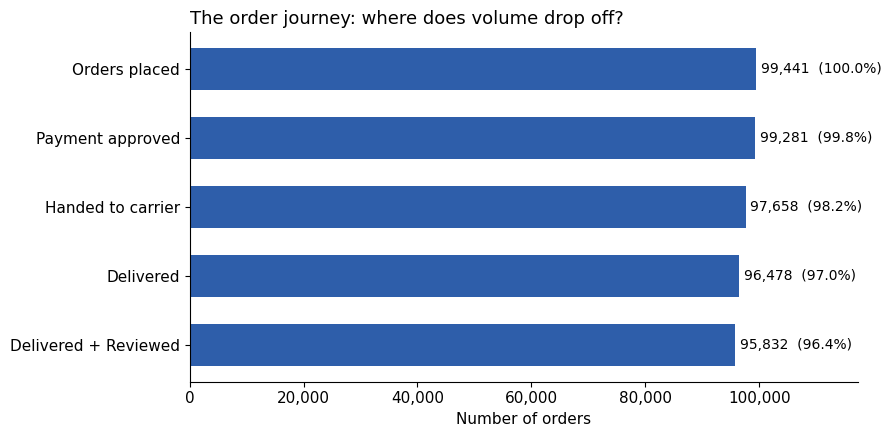

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))
y_pos = np.arange(len(funnel_stages))
bars = ax.barh(y_pos, funnel_stages.values, color=ACCENT, height=0.6)
ax.set_yticks(y_pos)
ax.set_yticklabels(funnel_stages.index)
ax.invert_yaxis()
ax.set_xlabel("Number of orders")
ax.set_title("The order journey: where does volume drop off?", fontsize=13, loc="left")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

for bar, stage in zip(bars, funnel_stages.index):
    width = bar.get_width()
    pct = funnel_pct[stage]
    ax.text(width + 800, bar.get_y() + bar.get_height()/2,
            f"{int(width):,}  ({pct}%)", va="center", fontsize=10)

ax.set_xlim(0, funnel_stages.max() * 1.18)
plt.tight_layout()
plt.show()

**Finding:** the funnel is remarkably clean. As 97.0% of orders reach delivery, and 96.3% of all orders placed end up both delivered and reviewed. There's no leaky multi stage funnel here; this is fundamentally a delivered orders dataset with a small, well understood tail of exceptions (canceled, unavailable, still in transit). That matters for how we read every other chart in this notebook: we're not fighting large scale funnel drop off, so the differences we'll see in review scores are really about delivery quality, not about who makes it to delivery at all.

## The central relationship: delivery delay vs. review score

This is the project's anchor finding. Delay is bucketed using the same reusable edges documented in `data_dictionary.md` : negative delay days mean the order arrived before the estimated date.

In [6]:
bins = [-200, -7, 0, 3, 7, 999]
labels = ["5+ days early", "on time/early", "1-3 days late", "4-7 days late", "8+ days late"]
delivered["delay_bucket"] = pd.cut(delivered["delivery_delay_days"], bins=bins, labels=labels)

delay_review = delivered.groupby("delay_bucket", observed=True)["review_score"].agg(mean="mean", n="count")
delay_review

,mean,n
delay_bucket,,
5+ days early,4.316782,70929
on time/early,4.200244,17234
1-3 days late,3.765933,2636
4-7 days late,2.318105,1773
8+ days late,1.726937,3252


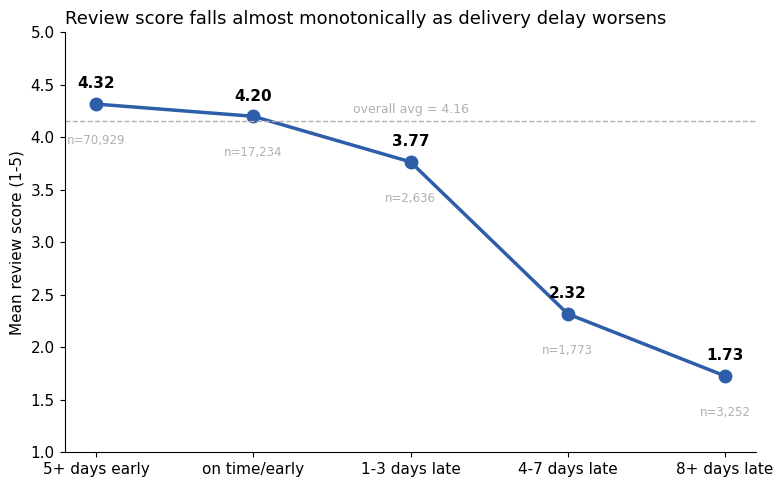

In [7]:
overall_mean = delivered["review_score"].mean()

fig, ax = plt.subplots(figsize=(8, 5))
x_pos = np.arange(len(delay_review))
ax.plot(x_pos, delay_review["mean"], marker="o", markersize=9, linewidth=2.5, color=ACCENT)

ax.axhline(overall_mean, color=NEUTRAL, linestyle="--", linewidth=1)
ax.text(2, overall_mean + 0.08, f"overall avg = {overall_mean:.2f}",
        color=NEUTRAL, fontsize=9, ha="center")

for x, (mean, n) in zip(x_pos, zip(delay_review["mean"], delay_review["n"])):
    ax.text(x, mean + 0.15, f"{mean:.2f}", ha="center", fontsize=11, fontweight="bold")
    ax.text(x, mean - 0.38, f"n={n:,}", ha="center", fontsize=8.5, color=NEUTRAL)

ax.set_xticks(x_pos)
ax.set_xticklabels(delay_review.index, rotation=0)
ax.set_ylim(1, 5)
ax.set_ylabel("Mean review score (1-5)")
ax.set_title("Review score falls almost monotonically as delivery delay worsens", fontsize=13, loc="left")
plt.tight_layout()
plt.show()

**Finding:** review score declines almost monotonically as delay worsens.
- From 4.32 for orders arriving 5+ days early down to 1.73 for orders 8+ days late, a 2.6 point collapse on a 5 point scale.
- The y-axis is kept at the full 1 to 5 scale (not zoomed in) since this is a bounded rating scale and truncating it would visually exaggerate a relationship that's already large and doesn't need help.
- Points are connected with a line because the delay buckets have a genuine order (Gestalt's Law of Continuity: connecting them lets the eye follow the trend rather than re-detecting five separate values).
- This is the single most important chart in the project as nearly every other finding either explains a piece of this relationship or complicates it.

## Decomposing delay: processing time vs. transport time

Delay isn't one thing. It's made of a seller controlled part (processing: purchase -> carrier handoff) and a mostly carrier controlled part (transport: carrier handoff -> delivery). Which one actually drives the relationship above?

In [8]:
proc_transport_means = delivered[["processing_days", "transport_days"]].mean()
proc_transport_means

,0
processing_days,3.227504
transport_days,9.330297


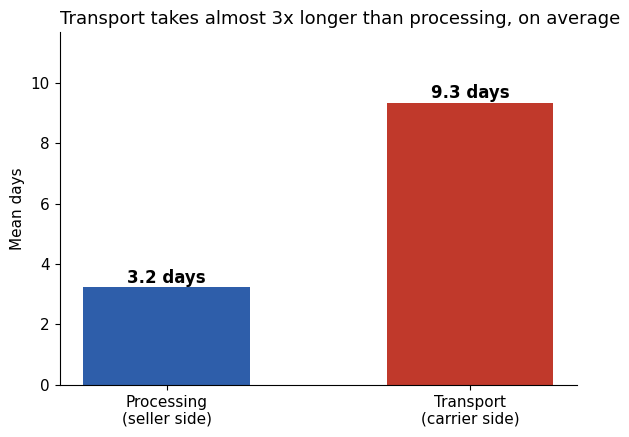

In [9]:
fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(["Processing\n(seller side)", "Transport\n(carrier side)"],
              proc_transport_means.values, color=[ACCENT, ACCENT_WARN], width=0.55)
for bar, val in zip(bars, proc_transport_means.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.15, f"{val:.1f} days",
            ha="center", fontsize=12, fontweight="bold")
ax.set_ylabel("Mean days")
ax.set_title("Transport takes almost 3x longer than processing, on average", fontsize=13, loc="left")
ax.set_ylim(0, max(proc_transport_means.values) * 1.25)
plt.tight_layout()
plt.show()

**Finding:** transport (9.3 days on average) takes roughly three times as long as processing (3.2 days) simply as a matter of time budget, the carrier has far more opportunity to introduce delay. That alone doesn't prove transport time matters more to satisfaction, though and the next chart tests that directly.

### Which one actually correlates with review score?

In [10]:
driver_cols = ["transport_days", "delivery_delay_days", "processing_days", "n_items",
               "freight_value", "distance_km", "order_item_value", "freight_ratio"]

driver_corr = delivered[driver_cols + ["review_score"]].corr()["review_score"].drop("review_score")
driver_corr = driver_corr.reindex(driver_corr.abs().sort_values(ascending=False).index)
driver_corr

,review_score
transport_days,-0.299411
delivery_delay_days,-0.267005
processing_days,-0.156957
n_items,-0.123167
freight_value,-0.077849
distance_km,-0.058907
order_item_value,-0.029388
freight_ratio,-0.022080


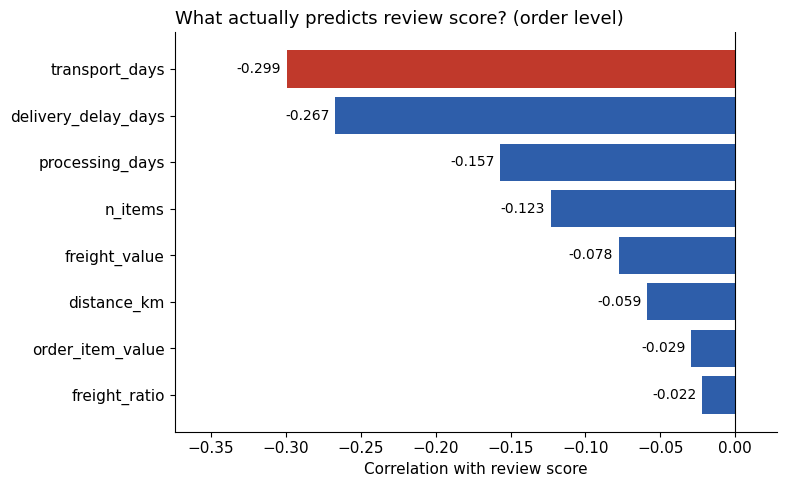

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
y_pos = np.arange(len(driver_corr))
colors = [ACCENT_WARN if abs(v) == driver_corr.abs().max() else ACCENT for v in driver_corr.values]
bars = ax.barh(y_pos, driver_corr.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(driver_corr.index)
ax.invert_yaxis()

ax.bar_label(bars, labels=[f"{v:.3f}" for v in driver_corr.values], padding=4, fontsize=10)
ax.set_xlim(driver_corr.min() * 1.25, driver_corr.max() + 0.05)

ax.set_xlabel("Correlation with review score")
ax.set_title("What actually predicts review score? (order level)", fontsize=13, loc="left")
plt.tight_layout()
plt.show()

**Finding:** `transport_days` is the single strongest correlate of review score (-0.30) surpassing `delivery_delay_days` itself (-0.27) and clearly ahead of `processing_days` (-0.16). Everything else (item count, freight, distance, price, freight ratio) are well behind.
- Bars (length encoding) are used here rather than color, since precise ranked comparison is exactly what the Cleveland McGill hierarchy says position/length is best at.
- Color would only be appropriate if we needed to show category, not magnitude.
- This is the first half of the paradox: the part of the journey mostly outside a seller's control matters more to the customer than the part the seller actually manages.

### The paradox's second half: does this flip at the seller level?

If transport time matters more to individual orders, does it also best identify which sellers are reliably good? To test this fairly, sellers with fewer than 5 orders (`seller_low_confidence`) are excluded first, a handful of lucky or unlucky orders can otherwise swing a small seller's average wildly, which would add noise rather than signal to a seller level correlation.

In [12]:
seller_avg_review = df.dropna(subset=["seller_id"]).groupby("seller_id")["review_score"].mean()
seller_avg_review.name = "seller_avg_review_score"

sellers = (df.dropna(subset=["seller_id"])
             .drop_duplicates(subset=["seller_id"])
             .set_index("seller_id")
             .join(seller_avg_review))

sellers_confident = sellers[sellers["seller_low_confidence"] == False]
print(f"Sellers before filtering: {len(sellers):,}")
print(f"Sellers after excluding low_confidence (n < 5 orders): {len(sellers_confident):,}")

Sellers before filtering: 3,085
Sellers after excluding low_confidence (n < 5 orders): 1,794


In [13]:
order_level_corr = {
    "processing_days": delivered["processing_days"].corr(delivered["review_score"]),
    "transport_days":  delivered["transport_days"].corr(delivered["review_score"]),
}
seller_level_corr = {
    "processing_days": sellers_confident["seller_avg_processing_days"].corr(sellers_confident["seller_avg_review_score"]),
    "transport_days":  sellers_confident["seller_avg_transport_days"].corr(sellers_confident["seller_avg_review_score"]),
}
pd.DataFrame({"order_level": order_level_corr, "seller_level": seller_level_corr})

,order_level,seller_level
processing_days,-0.156957,-0.448517
transport_days,-0.299411,-0.296245


/tmp/ipykernel_568/857707710.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["processing", "transport"])
/tmp/ipykernel_568/857707710.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["processing", "transport"])


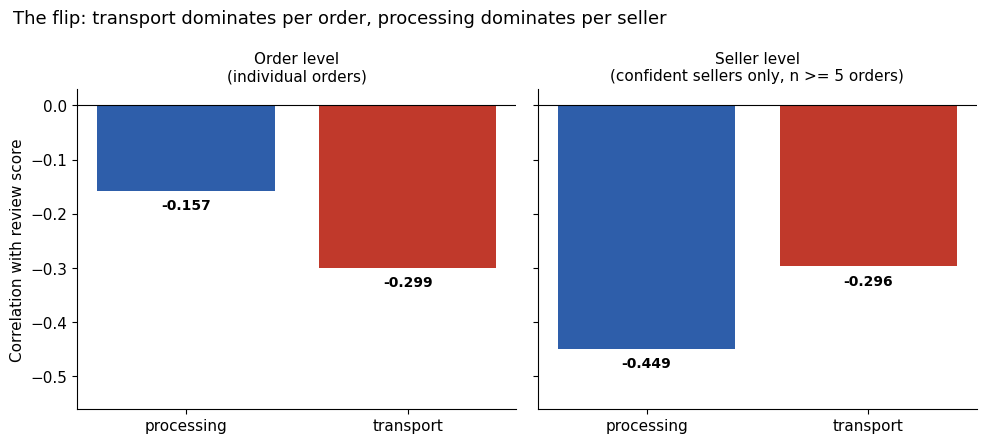

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharey=True)

for ax, (title, data) in zip(axes, [("Order level\n(individual orders)", order_level_corr),
                                     ("Seller level\n(confident sellers only, n >= 5 orders)", seller_level_corr)]):
    labels = list(data.keys())
    values = list(data.values())
    bars = ax.bar(labels, values, color=[ACCENT, ACCENT_WARN])

    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, v - 0.015, f"{v:.3f}",
                ha="center", va="top", fontsize=10, fontweight="bold", color="black")
    ax.set_title(title, fontsize=11)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticklabels(["processing", "transport"])
    ax.set_ylim(min(seller_level_corr.values()) * 1.25, 0.03)

axes[0].set_ylabel("Correlation with review score")
fig.suptitle("The flip: transport dominates per order, processing dominates per seller", fontsize=13, x=0.02, ha="left")
plt.tight_layout()
plt.show()

**Finding:** the ranking genuinely flips.
- At the order level, transport time has the stronger correlation (-0.30 vs. -0.16).
- At the seller level, processing time becomes the stronger correlate (-0.45 vs. -0.30).
- This is the paradox at the heart of the project's central story: transport time explains more of why any given order went badly (it's mostly weather/carrier/distance which is noisy but powerful per order), while a seller's own processing speed is a more consistent, controllable trait that reliably separates good sellers from bad ones over many orders.
- The practical implication: punishing individual sellers for delay driven by transport time targets the wrong thing for the customer facing problem, even though processing time remains a legitimate way to screen which sellers are dependable.

## Growth vs. quality: is the tension real, or just a story we're telling?

Monthly order volume and late delivery rate, over the full life of the dataset. Two kinds of months are excluded, both for documented reasons:

- **2018-09 and 2018-10** : Category A's investigation confirmed these are a dataset extraction artifact (orders too close to the pull date, 94-100% still showing as canceled/incomplete), not a real business collapse.

- **2016-09 and 2016-12** : the dataset's very first two active months, with only 4 and 1 orders respectively. A single order's outcome (e.g. one late delivery) would show as a 100% or 25% late rate and create a misleading spike before the marketplace had meaningfully launched. Excluded for the same small sample reason `low_confidence` sellers are handled elsewhere in this project not because the result is inconvenient, but because the `n` is too small to mean anything.

In [15]:
EXCLUDE_MONTHS = ["2016-09", "2016-12", "2018-09", "2018-10"]  # tiny n launch months + extraction tail artifact, not real signal

monthly = (df[~df["purchase_month"].isin(EXCLUDE_MONTHS)]
           .groupby("purchase_month")
           .agg(orders=("order_id", "count"), late_rate=("is_late", "mean"))
           .reset_index())
monthly.tail()

,purchase_month,orders,late_rate
16,2018-04,6939,0.052025
17,2018-05,6873,0.080896
18,2018-06,6167,0.013459
19,2018-07,6292,0.043865
20,2018-08,6512,0.101351


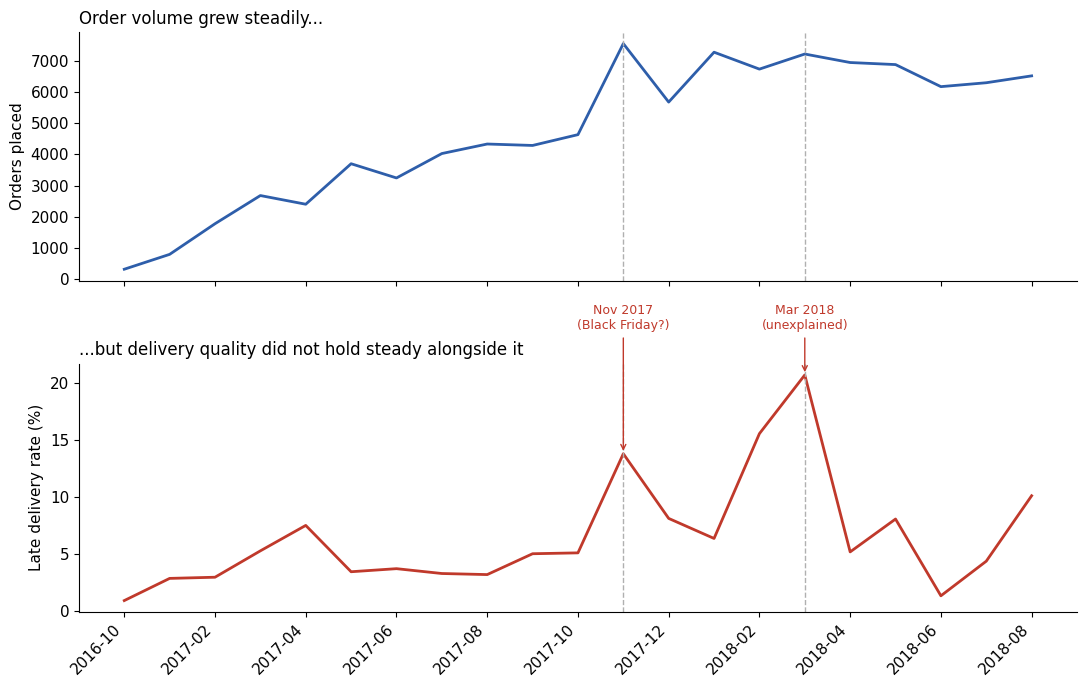

In [16]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

x_pos = np.arange(len(monthly))
ax1.plot(x_pos, monthly["orders"], color=ACCENT, linewidth=2)
ax1.set_ylabel("Orders placed")
ax1.set_title("Order volume grew steadily...", fontsize=12, loc="left")

ax2.plot(x_pos, monthly["late_rate"] * 100, color=ACCENT_WARN, linewidth=2)
ax2.set_ylabel("Late delivery rate (%)")
ax2.set_title("...but delivery quality did not hold steady alongside it", fontsize=12, loc="left")

# annotate the two real spikes
for month, label in [("2017-11", "Nov 2017\n(Black Friday?)"), ("2018-03", "Mar 2018\n(unexplained)")]:
    idx = monthly.index[monthly["purchase_month"] == month][0]
    for ax in (ax1, ax2):
        ax.axvline(idx, color=NEUTRAL, linestyle="--", linewidth=1)
    ax2.annotate(label, xy=(idx, monthly.loc[idx, "late_rate"] * 100),
                 xytext=(idx, monthly["late_rate"].max() * 100 + 4),
                 ha="center", fontsize=9, color=ACCENT_WARN,
                 arrowprops=dict(arrowstyle="->", color=ACCENT_WARN, lw=1))

ax2.set_xticks(x_pos[::2])
ax2.set_xticklabels(monthly["purchase_month"].iloc[::2], rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Finding:** order volume grows fairly steadily across the dataset's life, but the late delivery rate is far from flat alongside it and two real spikes stand out.
- November 2017 (13.8% late, vs. 5% in surrounding months) possibly lines up with Black Friday demand. March 2018 (20.7% late) is a bigger spike with no obvious explanation in this data alone which is flagged honestly as an open question rather than guessed at.
- The two panels share the x-axis rather than using a dual axis chart on one panel because a dual axis with two different units (order count, percentage) makes it too easy to visually imply a causal or proportional relationship that isn't really there (Week 6's lesson about axis/framing choices not being neutral).

### Cross validation: does the same March 2018 signal show up independently in customer reviews?

Track A found the late rate spike above by looking only at delivery timing data. Track D, working independently from review data, flagged the same month as unusually bad. If both are real, they should show up together here.

In [17]:
monthly_review = (delivered[~delivered["purchase_month"].isin(EXCLUDE_MONTHS)]
                   .groupby("purchase_month")["review_score"].mean()
                   .reset_index())
monthly_check = monthly.merge(monthly_review, on="purchase_month", how="left")
monthly_check[monthly_check["purchase_month"].isin(["2017-10","2017-11","2017-12","2018-01","2018-02","2018-03","2018-04"])]

,purchase_month,orders,late_rate,review_score
10,2017-10,4631,0.051177,4.204903
11,2017-11,7544,0.138256,3.988809
12,2017-12,5673,0.081438,4.088445
13,2018-01,7269,0.063833,4.108513
14,2018-02,6728,0.155916,3.880590
15,2018-03,7211,0.207461,3.812464
16,2018-04,6939,0.052025,4.205865


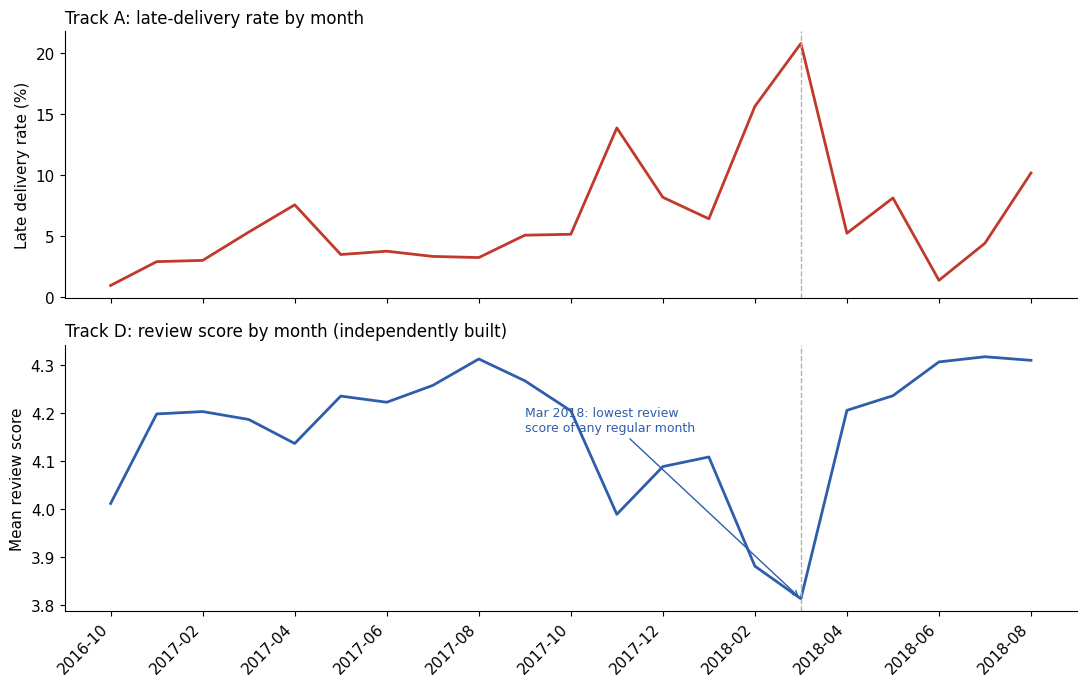

In [18]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
x_pos = np.arange(len(monthly_check))

ax1.plot(x_pos, monthly_check["late_rate"] * 100, color=ACCENT_WARN, linewidth=2)
ax1.set_ylabel("Late delivery rate (%)")
ax1.set_title("Track A: late-delivery rate by month", fontsize=12, loc="left")

ax2.plot(x_pos, monthly_check["review_score"], color=ACCENT, linewidth=2)
ax2.set_ylabel("Mean review score")
ax2.set_title("Track D: review score by month (independently built)", fontsize=12, loc="left")

idx = monthly_check.index[monthly_check["purchase_month"] == "2018-03"][0]
for ax in (ax1, ax2):
    ax.axvline(idx, color=NEUTRAL, linestyle="--", linewidth=1)
ax2.annotate("Mar 2018: lowest review\nscore of any regular month",
             xy=(idx, monthly_check.loc[idx, "review_score"]),
             xytext=(idx - 6, monthly_check["review_score"].min() + 0.35),
             fontsize=9, color=ACCENT,
             arrowprops=dict(arrowstyle="->", color=ACCENT, lw=1))

ax2.set_xticks(x_pos[::2])
ax2.set_xticklabels(monthly_check["purchase_month"].iloc[::2], rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Finding:** March 2018 shows up in both series as the highest late delivery rate (20.7%) and the lowest average review score of any regular month (3.81, versus a typical 4.1-4.3).

- These two numbers were computed from entirely different columns by two people working independently, which makes this strong evidence the spike is a genuine, customer felt event rather than a data artifact in either track.

- What this chart deliberately does not do is, claim a cause. The underlying reason for March 2018's trouble is still unknown from this data alone, and that will be stated directly in the report.

## Zooming in: which end of the scale actually moved in March 2018?

The chart above shows March 2018's average review score dropping. But a bimodal distribution's average can drop two different ways: more 1 star reviews, or fewer 5 star reviews. Breaking the monthly distribution into its five components shows which one actually happened.

In [19]:
monthly_dist = (delivered[~delivered["purchase_month"].isin(EXCLUDE_MONTHS)]
                .groupby(["purchase_month", "review_score"]).size()
                .unstack(fill_value=0))
monthly_pct = monthly_dist.div(monthly_dist.sum(axis=1), axis=0) * 100
monthly_pct.loc[["2018-01", "2018-02", "2018-03", "2018-04"]].round(1)

review_score,1.0,2.0,3.0,4.0,5.0
purchase_month,,,,,
2018-01,10.3,3.4,9.3,19.1,57.9
2018-02,15.6,3.7,9.4,19.3,51.9
2018-03,17.5,3.7,9.2,19.3,50.3
2018-04,8.7,3.1,7.5,20.3,60.4


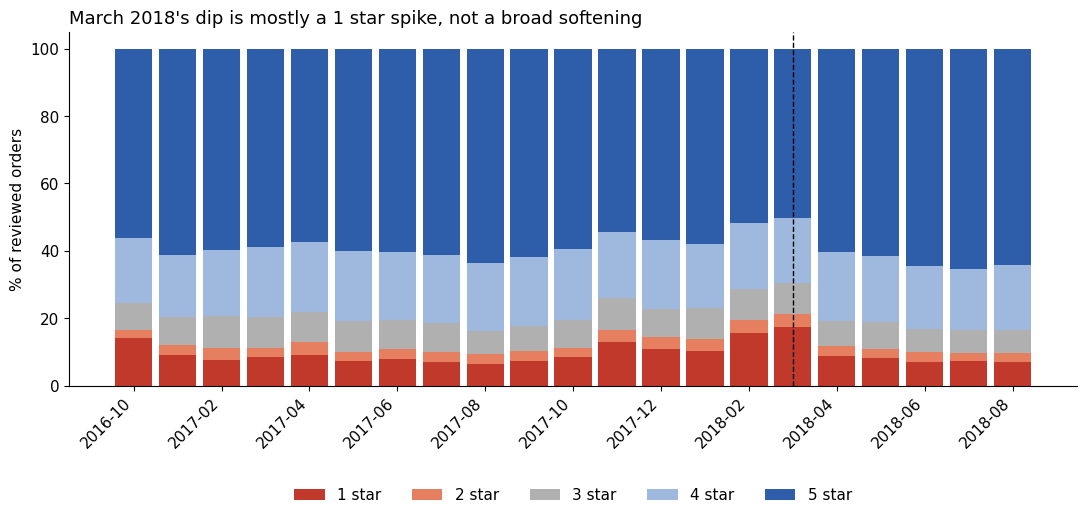

In [20]:
fig, ax = plt.subplots(figsize=(11, 5.5))
x_pos = np.arange(len(monthly_pct))
colors = [ACCENT_WARN, "#E67E60", NEUTRAL, "#9FB8DE", ACCENT]

bottom = np.zeros(len(monthly_pct))
for score, color in zip([1.0, 2.0, 3.0, 4.0, 5.0], colors):
    ax.bar(x_pos, monthly_pct[score], bottom=bottom, color=color, width=0.85, label=f"{int(score)} star")
    bottom += monthly_pct[score].values

march_idx = list(monthly_pct.index).index("2018-03")
ax.axvline(march_idx, color="black", linestyle="--", linewidth=1)

ax.set_xticks(x_pos[::2])
ax.set_xticklabels(monthly_pct.index[::2], rotation=45, ha="right")
ax.set_ylabel("% of reviewed orders")
ax.set_title("March 2018's dip is mostly a 1 star spike, not a broad softening", fontsize=13, loc="left")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.25), ncol=5, frameon=False)
plt.tight_layout()
plt.show()

**Finding:** March 2018's 1 star share jumps to 17.5% (typical months run 7 to 9%), roughly double the normal rate

- While the 5 star share drops to 50.3% from a typical 57 to 64%, a real but proportionally smaller move.

- February 2018 shows the same pattern at a smaller scale (15.6% 1 star).

- This means March 2018's problem wasn't a general, mild dip in satisfaction across the board, it was specifically a surge in the worst outcomes, consistent with a real operational failure (e.g. a batch of badly delayed deliveries) rather than a broad, softer decline that might point to something like a pricing or product quality issue instead.

## Where to invest: how concentrated is the marketplace among its sellers?

If a small number of sellers handle most of the volume, marketplace wide delivery performance is really a story about that small group, not the average seller.

In [21]:
sellers_ranked = sellers.dropna(subset=["seller_n_orders"]).sort_values("seller_n_orders", ascending=False).reset_index(drop=True)
sellers_ranked["cum_pct_orders"] = sellers_ranked["seller_n_orders"].cumsum() / sellers_ranked["seller_n_orders"].sum() * 100
sellers_ranked["cum_pct_sellers"] = (sellers_ranked.index + 1) / len(sellers_ranked) * 100

top10_row = sellers_ranked.iloc[int(len(sellers_ranked) * 0.10)]
print(f"Top 10% of sellers ({int(len(sellers_ranked)*0.10):,} of {len(sellers_ranked):,}) "
      f"handle {top10_row['cum_pct_orders']:.1f}% of all orders")

Top 10% of sellers (308 of 3,085) handle 68.4% of all orders


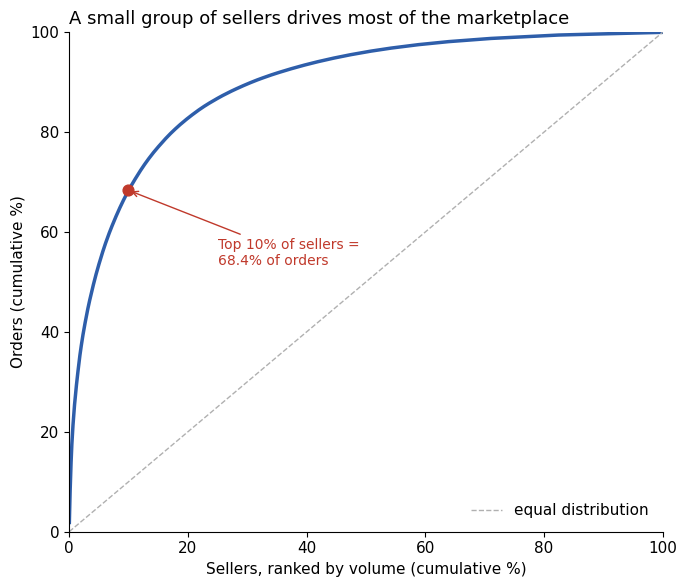

In [22]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(sellers_ranked["cum_pct_sellers"], sellers_ranked["cum_pct_orders"], color=ACCENT, linewidth=2.5)
ax.plot([0, 100], [0, 100], color=NEUTRAL, linestyle="--", linewidth=1, label="equal distribution")

ax.scatter([10], [top10_row["cum_pct_orders"]], color=ACCENT_WARN, zorder=5, s=60)
ax.annotate(f"Top 10% of sellers =\n{top10_row['cum_pct_orders']:.1f}% of orders",
            xy=(10, top10_row["cum_pct_orders"]), xytext=(25, top10_row["cum_pct_orders"] - 15),
            fontsize=10, color=ACCENT_WARN,
            arrowprops=dict(arrowstyle="->", color=ACCENT_WARN, lw=1))

ax.set_xlabel("Sellers, ranked by volume (cumulative %)")
ax.set_ylabel("Orders (cumulative %)")
ax.set_title("A small group of sellers drives most of the marketplace", fontsize=13, loc="left")
ax.legend(loc="lower right", frameon=False)
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

**Finding:** the top 10% of sellers by volume (roughly 308 of 3,085) account for about 68% of all orders which is a long way from the diagonal or the everyone contributes equally reference line.

- This directly answers where should the company invest: marketplace wide delivery performance is disproportionately determined by how well a small group of high volume sellers is supported (better tools, dedicated account management, priority carrier arrangements), not by broad, uniform policy changes aimed at the median seller.

## Summary

1. The order journey is clean (97% reach delivery) : differences in review score are genuinely about delivery quality, not funnel leakage.
2. Delay predicts review score almost monotonically : the project's anchor relationship.
3. The paradox: transport time dominates at the order level, but processing time is the better signal for which sellers are reliably good.
4. Growth and delivery quality did not move together : real spikes (Nov 2017, Mar 2018) interrupt an otherwise steady volume trend, and the Mar 2018 dip is independently confirmed in review data, even though its cause remains unknown.
5. Marketplace performance is concentrated: the top 10% of sellers handle 68% of orders, the highest leverage place to invest.